# BBM418 / AIN433 — Fundamentals of Computer Vision  
## Programming Assignment 2: Object Localization and Single-Object Tracking

### Student Notebook

This notebook is the starter template for the assignment. This is a draft.
You can follow the given structure or you can implement your version.
Feel free to change given code templates.

The assignment has five main parts:

1. Dataset loading and visualization  
2. Search-region sample generation  
3. CNN-based bounding-box regression model  
4. Single-object tracking on validation and test sequences  
5. Validation evaluation and analysis  

Keep your implementation clean, reproducible, and easy to follow.

### Student Info

#### Name: Mahmut Özkızılcık

#### ID: 2220765019

## Assignment Setting

You will work with the given single-object tracking dataset.

### Training and Validation Sequences

These contain full ground-truth annotations:

```text
SequenceName/
  img/
    0001.jpg
    0002.jpg
    ...
  groundtruth_rect.txt
```

### Test Sequences

These contain only the first-frame initialization box:

```text
SequenceName/
  img/
    0001.jpg
    0002.jpg
    ...
  init_rect.txt
```

## Important Rule

For validation and test tracking, you may use only the first-frame bounding box to initialize the tracker.

After the first frame, all bounding boxes must be predicted by your tracker.

For validation sequences, later ground-truth boxes may be used **only after tracking** to compute evaluation metrics.

For test sequences, ground truth is hidden and must not be used.

## Expected Output

Your notebook should generate prediction CSV files for the test sequences.

Each file must be saved as:

```text
outputs/test/<sequence_name>_predictions.csv
```

The required CSV format is:

```text
frame,x,y,w,h
1,198,214,34,81
2,197.2,214.1,34.5,80.7
3,195.4,213.9,34.8,81.2
```

Coordinates must be full-frame pixel coordinates in `(x, y, width, height)` format. Do **not** save normalized crop coordinates.

# 0. Imports and Configuration

Run this section first. You may add extra imports if needed.

Make sure the paths below match your local folder structure.

In [3]:
import os
import csv
import math
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms

In Google Colab environment, to download the dataset and extract it to the working directory you may use the following cell.

In [2]:
"""# 1. Configuration
FILE_ID = '1q8AAAQ64QwA16gU5jEKDvPure7CVajUt'
ZIP_NAME = 'dataset.zip'

# 2. Download the file
!gdown --id {FILE_ID} -O {ZIP_NAME}

# 3. Extract directly to /content
# This will result in: /content/data/sequences/ and /content/data/splits/
!unzip -q {ZIP_NAME} -d /content/

# 4. Cleanup the zip file
!rm {ZIP_NAME}

# 5. Verify the structure
print("Files in /content/data:", os.listdir("/content/data"))"""

'# 1. Configuration\nFILE_ID = \'1q8AAAQ64QwA16gU5jEKDvPure7CVajUt\'\nZIP_NAME = \'dataset.zip\'\n\n# 2. Download the file\n!gdown --id {FILE_ID} -O {ZIP_NAME}\n\n# 3. Extract directly to /content\n# This will result in: /content/data/sequences/ and /content/data/splits/\n!unzip -q {ZIP_NAME} -d /content/\n\n# 4. Cleanup the zip file\n!rm {ZIP_NAME}\n\n# 5. Verify the structure\nprint("Files in /content/data:", os.listdir("/content/data"))'

## Reproducibility

Set random seeds so your results are more reproducible.
Include your seeds if you introduce additional randomness.

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Paths and Hyperparameters

Update `DATA_ROOT` if your dataset is located somewhere else.

The suggested hyperparameters are only starting points. You may change them, but report your final choices in the discussion section.

In [5]:
DATA_ROOT = Path("dataset/data/sequences")
SPLIT_ROOT = Path("dataset/data/splits")

OUTPUT_ROOT = Path("outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224
SEARCH_SCALE = 2.5
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_WORKERS = 0

print("Device:", DEVICE)
print("DATA_ROOT:", DATA_ROOT)

Device: cuda
DATA_ROOT: dataset\data\sequences


# PART 1 — Dataset Loading and Visualization

In this part, you will implement utilities for loading the dataset and visualizing bounding boxes.

You need separate loading functions for:

- training/validation sequences with `groundtruth_rect.txt`,
- test sequences with `init_rect.txt`.

This distinction is important because test sequences do not contain full ground truth.

## 1.1 Bounding-Box File Reader

The annotation files contain bounding boxes in the format:

```text
x,y,width,height
```

Some files may use commas, spaces, or tabs as separators. Your parser should handle these cases.

In [6]:
def read_bbox_file(path: Path) -> np.ndarray:
    """
    Reads bounding-box file.

    The file may contain one line or multiple lines.
    Each line has:
        x, y, width, height

    The parser should handle comma-separated, tab-separated,
    and whitespace-separated values.

    Returns:
        bboxes: numpy array of shape (N, 4)
    """
    
    with open(path, 'r') as file:
        bboxes = []
        for line in file:
            line = line.strip()
            line = line.replace(',',' ')
            if not line:
                continue

            bbox = [float(x) for x in line.split()]
            bboxes.append(bbox)
            
                
    return np.array(bboxes, dtype=np.float32)

## 1.2 Frame Path Reader

This function should read all frame paths from the `img/` folder and sort them in frame order.

In [7]:
def get_frame_paths(sequence_path: Path) -> List[Path]:
    """
    Return sorted frame paths from sequence_path/img/.

    Returns:
        frame_paths: sorted list of image paths
    """
    img_dir =  sequence_path / "img"
    frame_paths = list(img_dir.glob("*.jpg"))   # All jpg files
    sorted_paths = sorted(frame_paths, key=lambda p: int(p.stem)) # sorted


    return sorted_paths

## 1.3 Load Training / Validation Sequences

Training and validation sequences contain full ground truth.

Your loader must check that:

```text
number of frames == number of ground-truth boxes
```

If there is a mismatch, raise an error. Do not silently truncate frames or annotations.

In [8]:
def load_sequence_with_gt(sequence_path: Path) -> Tuple[List[Path], np.ndarray]:
    """
    Loads a training or validation sequence.

    Expected files:
        img/
        groundtruth_rect.txt

    Returns:
        frame_paths: sorted list of image paths
        bboxes: numpy array of shape (N, 4)

    Required check:
        len(frame_paths) must equal len(bboxes).
    """

    frame_paths = get_frame_paths(sequence_path)
    bboxes = read_bbox_file( sequence_path / "groundtruth_rect.txt")

    if len(frame_paths) != len(bboxes):
        raise ValueError("Frames and boxes not equal")
    return frame_paths, bboxes

## 1.4 Load Test Sequences

Test sequences contain only `init_rect.txt`.

This file contains one bounding box: the first-frame initialization box.

Your test loader should not expect `groundtruth_rect.txt`.

In [9]:
def load_test_sequence(sequence_path: Path) -> Tuple[List[Path], np.ndarray]:
    """
    Load a hidden test sequence.

    Expected files:
        img/
        init_rect.txt

    Returns:
        frame_paths: sorted list of image paths
        initial_bbox: numpy array of shape (4,)
    """

    frame_paths = get_frame_paths(sequence_path)
    bboxes = read_bbox_file(sequence_path / "init_rect.txt")
    initial_bbox = bboxes[0]

    return frame_paths, initial_bbox

## 1.5 Image Reading and Drawing Utilities

Implement helper functions for reading RGB images and drawing bounding boxes.

These functions will be used throughout the notebook.

In [14]:
def read_image_rgb(path: Path) -> np.ndarray:
    """
    Read an image using OpenCV and convert it from BGR to RGB.
    """
    img_bgr = cv2.imread(str(path)) # read image as bgr
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # convert it to rgb form

    return img_rgb


def draw_bbox(
    image: np.ndarray,
    bbox: np.ndarray,
    color: Tuple[int, int, int] = (0, 255, 0),
    thickness: int = 2,
    label: Optional[str] = None,
) -> np.ndarray:
    """
    Draw a bounding box on an RGB image.

    Args:
        image: input RGB image
        bbox: bounding box in (x, y, w, h) format
        color: RGB color
        thickness: line thickness
        label: optional label text

    Returns:
        image_with_box
    """

    image_copy = image.copy() # to not do implace modification take a copy of the image
    x = int(bbox[0])
    y = int(bbox[1])
    w = int(bbox[2])
    h = int(bbox[3])

    cv2.rectangle(image_copy, (x, y), (x + w, y + h), color, thickness) # make a rectangle

    if label is not None:
        text_y = max(y - 7, 15)
        cv2.putText(image_copy, label, (x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1) # label check

    return image_copy

def show_image(image: np.ndarray, title: str = "", figsize: Tuple[int, int] = (6, 4)):
    """Display an RGB image using matplotlib."""
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    plt.show()

## 1.6 Sequence Listing

This helper is useful for checking which sequences exist under `DATA_ROOT`.

In [15]:

def list_sequences(data_root: Path) -> List[str]:
    """
    List valid sequence folders inside data_root.
    """
    sequences = []
    for path in data_root.iterdir():
        if path.is_dir():
            sequences.append(path.name)
    
    return sorted(sequences)

## 1.7 Visualization Task

Visualize at least five frames from at least two training/validation sequences.

For each visualized frame, draw the ground-truth bounding box.

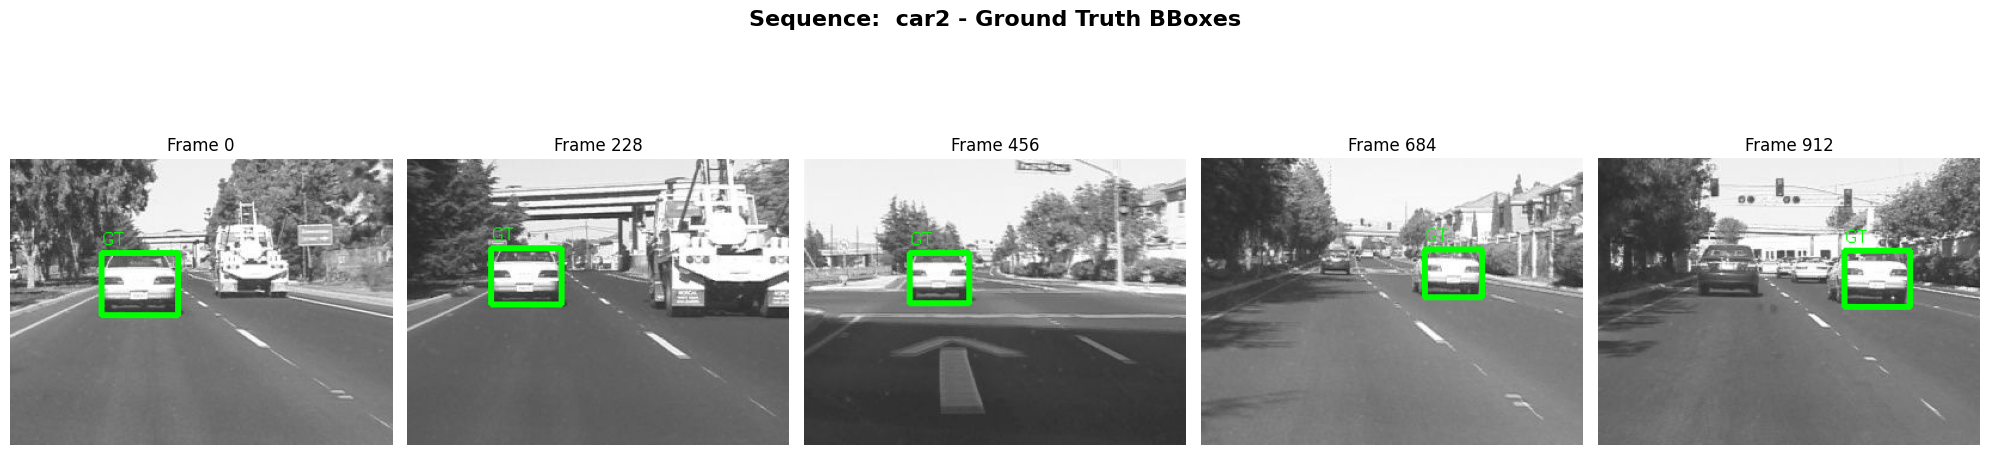

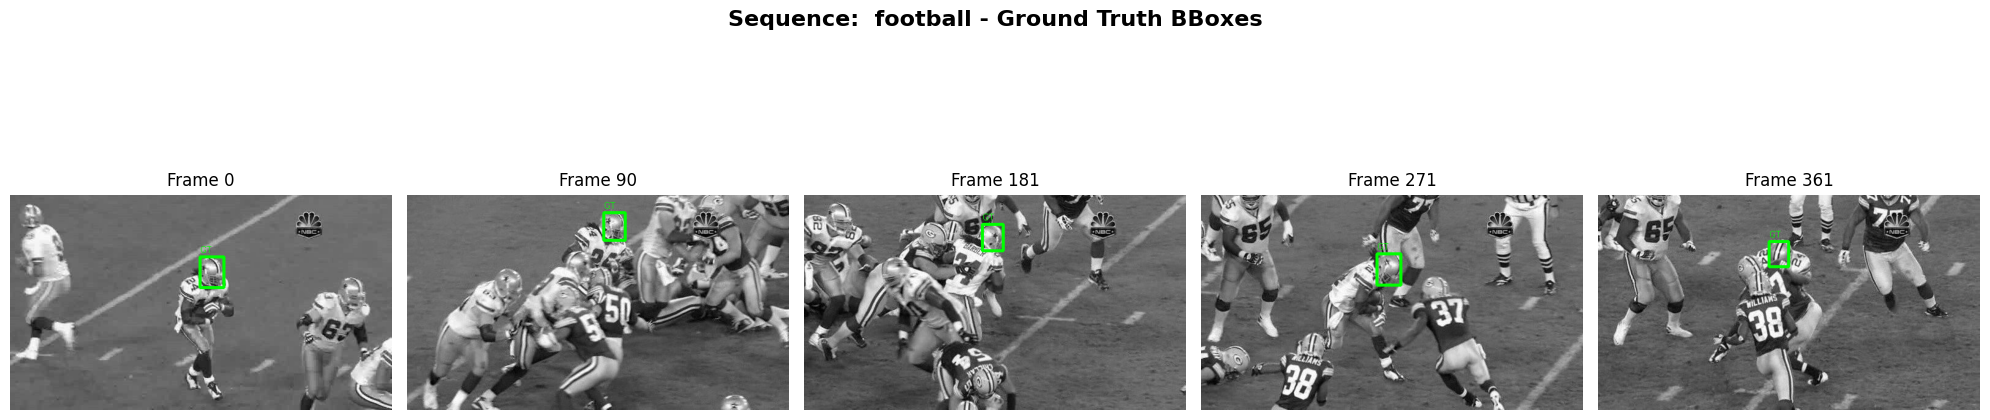

In [16]:
sequences_to_visualize = ["car2", "football"]
for sequance_name in sequences_to_visualize:
    # Load sequencse
    seq_path = DATA_ROOT / sequance_name
    frame_paths, bboxes = load_sequence_with_gt(seq_path)

    # 5 square index with same weight
    total_frames = len(frame_paths)
    indices = [
        0, 
        total_frames // 4, 
        total_frames // 2, 
        3 * total_frames // 4, 
        total_frames - 1
    ]

    # 5 image in a row
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    for ax, idx in zip(axes, indices):
        # Read iammge
        img = read_image_rgb(frame_paths[idx])
        # Ground trurt label
        img_boxed = draw_bbox(img, bboxes[idx], color=(0, 255, 0), thickness=3, label="GT")

        # Draw image
        ax.imshow(img_boxed)
        ax.set_title(f"Frame {idx}", fontsize=12)
        ax.axis("off")
        
    plt.suptitle(f"Sequence:  {sequance_name} - Ground Truth BBoxes", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / f"dataset_viz_{sequance_name}.png", bbox_inches='tight', dpi=100)
    plt.show()


    

# Split Handling

The assignment uses fixed train/validation/test splits.

Use only the provided split files:

```text
splits/train.txt
splits/val.txt
splits/test.txt
```

Each file contains one sequence name per line.

## Split File Loading

Implement the functions below to read split files and verify that the sequence folders match the expected format.

In [17]:
from os import read
def read_split_file(split_path: Path) -> List[str]:
    """Read sequence names from a split file."""
    lines = []
    with open(split_path, 'r') as file:
        for line in file:
            lines.append(line.strip())
        
    return lines


def load_splits(split_root: Path) -> Tuple[List[str], List[str], List[str]]:
    """Load train, validation, and test split files."""
    train_seqs = read_split_file(split_root / "train.txt")
    val_seqs = read_split_file(split_root / "val.txt")
    test_seqs = read_split_file(split_root / "test.txt")
    return train_seqs, val_seqs, test_seqs


def verify_split_files(
    data_root: Path,
    train_sequences: List[str],
    val_sequences: List[str],
    test_sequences: List[str],
):
    """
    Verify that train/val sequences have groundtruth_rect.txt
    and test sequences have init_rect.txt.
    """
    for seq in train_sequences + val_sequences:
        gt_path = data_root / seq / "groundtruth_rect.txt"
        if not gt_path.exists():
            raise FileNotFoundError(f"gt PAth does not exits !.{gt_path}")

    for seq in test_sequences:
        init_path = data_root / seq / "init_rect.txt"
        if not init_path.exists():
            raise FileNotFoundError(f"init_rect.txt does not exists! {init_path}")


    print("Files are all correct")



## Load Splits

Run this cell after implementing the split-loading functions.

In [18]:
train_seqs, val_seqs, test_seqs = load_splits(SPLIT_ROOT)

verify_split_files(DATA_ROOT, train_seqs, val_seqs, test_seqs)

print(f"Train split size: {len(train_seqs)} sequences")
print(f"Val split size: {len(val_seqs)} sequences")
print(f"Test split size: {len(test_seqs)} sequences")


Files are all correct
Train split size: 39 sequences
Val split size: 11 sequences
Test split size: 7 sequences


# (Optional) Dataset Exploration

This section is not required for implementation, but it is helpful for understanding the dataset.

You may use these cells to inspect:

- sequence lengths,
- bounding-box size distribution,
- object trajectory,
- scale changes.

These visualizations can also help your discussions.

## (Optional) Dataset Summary

After loading the splits, summarize the number of frames and bounding-box sizes in the training and validation sets.

In [19]:
# TODO: Optional dataset summary.

## (Optional) Bounding-Box Distribution

Plot distributions of bounding-box width, height, area, or aspect ratio.

In [20]:
# TODO: Optional bounding-box distribution plots.

# Example ideas:
# - histogram of bbox widths
# - histogram of bbox heights
# - histogram of bbox areas
# - histogram of aspect ratios

## (Optional) Target Motion Visualization

For one selected sequence, plot the target center coordinates over time.

In [21]:
# TODO: Optional trajectory visualization.

# PART 2 — Search-Region Sample Generation

In single-object tracking, the target is initialized in the first frame. For later frames, the tracker searches around the previous target location.

In this assignment, you will train a model that receives a local search crop and predicts the target box inside that crop.

For a pair of consecutive frames:

```text
Frame t-1 bbox -> used to define the search region in frame t
Frame t bbox   -> target label inside the search region
```

## 2.1 Crop Metadata

`CropInfo` stores the information needed to convert between:

- full-frame coordinates,
- crop-local normalized coordinates.

In [22]:
@dataclass
class CropInfo:
    """
    Metadata for mapping between crop coordinates and full-frame coordinates.

    x1, y1:
        Top-left location of the crop in the original image coordinate system.
        These may be negative if padding is used.

    crop_size:
        Side length of the square crop in original image pixels.

    output_size:
        Side length after resizing the crop for the CNN.
    """
    x1: float
    y1: float
    crop_size: float
    output_size: int

## 2.2 Bounding-Box Helper Functions

Implement simple helper functions for bounding-box center computation and clipping predictions to image boundaries.

In [23]:
def bbox_center(bbox: np.ndarray) -> Tuple[float, float]:
    """Compute the center of a bbox in (x, y, w, h) format."""
    cx = float(bbox[0] + bbox[2] / 2.0)
    cy = float(bbox[1] + bbox[3] / 2.0)
    return cx, cy



def clip_bbox_to_image(bbox: np.ndarray, image_shape: Tuple[int, int, int]) -> np.ndarray:
    """Clip a bbox to image boundaries and keep width/height positive."""
    height, width = image_shape[0], image_shape[1]

    # get corners
    x1, y1 = bbox[0], bbox[1]
    x2 = x1 + bbox[2]
    y2 = y1 + bbox[3]
     # clip corners 
    x1_clipped = np.clip(x1, 0, width)
    y1_clipped = np.clip(y1, 0, height)
    x2_clipped = np.clip(x2, 0, width)
    y2_clipped = np.clip(y2, 0, height)

    # calculate new witdh and height(at least 1 pixel)
    w_clipped = float(max(x2_clipped - x1_clipped, 1.0))
    h_clipped = float(max(y2_clipped - y1_clipped, 1.0))
    
    return np.array([x1_clipped, y1_clipped, w_clipped, h_clipped], dtype=np.float32)

## 2.3 Search-Region Crop

Use a square search region centered around the previous bounding box.

The recommended crop size is:

```text
crop_size = scale × max(previous_width, previous_height)
```

A reasonable default value is `scale = 2.5`.

If the crop goes outside the image, handle the boundary carefully. You may use padding or clipping, but your coordinate conversion must remain correct.

In [24]:
def crop_search_region(
    image: np.ndarray,
    previous_bbox: np.ndarray,
    scale: float = 2.5,
    output_size: int = IMAGE_SIZE,
    pad_value: Tuple[int, int, int] = (128, 128, 128),
) -> Tuple[np.ndarray, CropInfo]:
    """
    Crop a square search region around the previous bounding box.

    Returns:
        crop_resized: RGB crop resized to output_size x output_size
        crop_info: metadata for coordinate conversion
    """
    
    # center and crop size
    cx, cy = bbox_center(previous_bbox)
    w_prev = previous_bbox[2]
    h_prev = previous_bbox[3]
    crop_size = scale * max(w_prev, h_prev)
    
    # coordinates of the search square 
    x1 = cx - crop_size / 2.0
    y1 = cy - crop_size / 2.0
    x2 = x1 + crop_size
    y2 = y1 + crop_size

    # boundaries for image extraction
    img_h, img_w = image.shape[0], image.shape[1]
    x1_img = max(0, int(round(x1)))
    y1_img = max(0, int(round(y1)))
    x2_img = min(img_w, int(round(x2)))
    y2_img = min(img_h, int(round(y2)))
    
    # crop image
    img_crop = image[y1_img:y2_img, x1_img:x2_img]

    # pad amounts calculation

    pad_left = max(0, int(round(0 - x1)))
    pad_top = max(0, int(round(0 - y1)))
    pad_right = max(0, int(round(x2 - img_w)))
    pad_bottom = max(0, int(round(y2 - img_h)))
    
    # constant border padding
    padded_crop = cv2.copyMakeBorder(
        img_crop,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        borderType=cv2.BORDER_CONSTANT,
        value=pad_value
    )

    # resize process

    crop_resized = cv2.resize(padded_crop, (output_size, output_size))


    # Crop metadata

    crop_info = CropInfo(
        x1=float(x1),
        y1=float(y1),
        crop_size=float(crop_size),
        output_size=int(output_size)
    )
    
    return crop_resized, crop_info


## 2.4 Coordinate Conversion

The model predicts boxes inside the crop, but the final tracking output must be in full-frame coordinates.

You need two conversions:

1. Full-frame bbox → crop-local normalized bbox  
2. Crop-local normalized bbox → full-frame bbox

In [25]:
def bbox_to_crop_coordinates(bbox: np.ndarray, crop_info: CropInfo) -> np.ndarray:
    """
    Convert a full-frame bbox into normalized crop coordinates.

    Returns:
        normalized_bbox: (x, y, w, h), usually in [0, 1]
    """
    # shift the origin to the crop's top-left corner
    x_local = bbox[0] - crop_info.x1
    y_local = bbox[1] - crop_info.y1
    
    # Normalize by the crop size
    x_norm = x_local / crop_info.crop_size
    y_norm = y_local / crop_info.crop_size
    w_norm = bbox[2] / crop_info.crop_size
    h_norm = bbox[3] / crop_info.crop_size
    
    return np.array([x_norm, y_norm, w_norm, h_norm], dtype=np.float32)


def crop_to_frame_coordinates(normalized_bbox: np.ndarray, crop_info: CropInfo) -> np.ndarray:
    """
    Convert a normalized crop-local bbox back to full-frame coordinates.
    """
     # denormalize 
    x_local = normalized_bbox[0] * crop_info.crop_size
    y_local = normalized_bbox[1] * crop_info.crop_size
    w = normalized_bbox[2] * crop_info.crop_size
    h = normalized_bbox[3] * crop_info.crop_size
    
    # shift back to the original image coordinate system
    x = x_local + crop_info.x1
    y = y_local + crop_info.y1

    return np.array([x, y, w, h], dtype=np.float32)


## 2.5 Search-Region Visualization

Visualize several generated search-region samples.

For each sample, draw the current target box inside the search crop.

This is one of the most important sanity checks in the assignment.

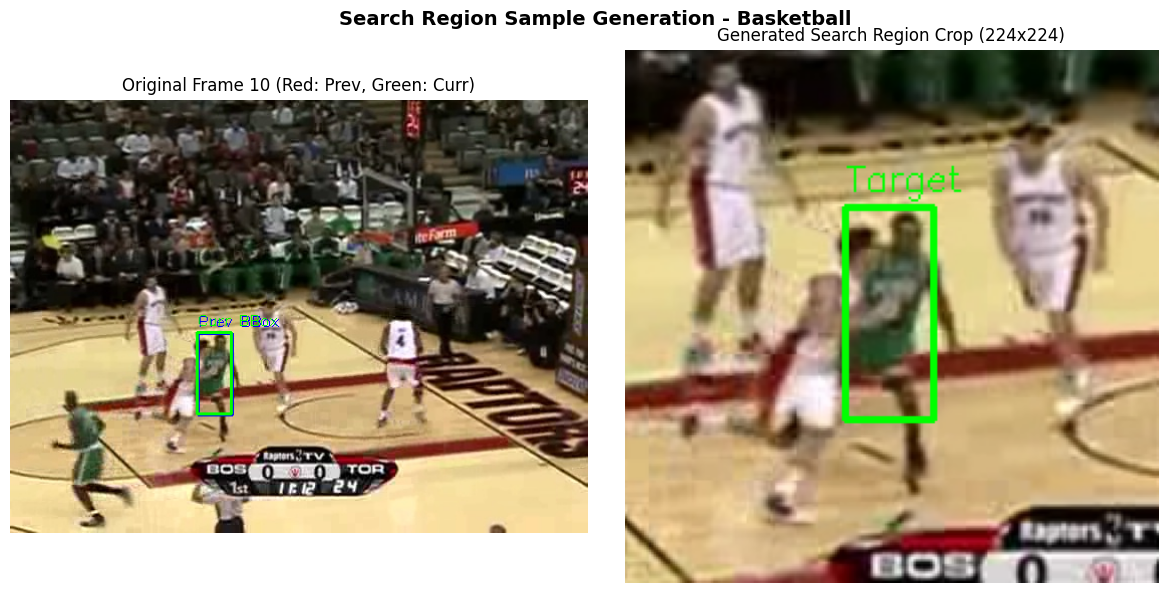

In [26]:
# load a sequence and get frame paths and bounding boxes
sequence_name = "Basketball"
frame_paths, bboxes = load_sequence_with_gt(DATA_ROOT / sequence_name)

# select a frame pair
t = 10  # current frame index
prev_frame_path = frame_paths[t - 1]
curr_frame_path = frame_paths[t]

bbox_prev = bboxes[t - 1]  # bbox in frame t-1 
bbox_curr = bboxes[t]      # target BBox in frame t

# read the current frame image
img_curr = read_image_rgb(curr_frame_path)

# crop search region from frame t around bbox_prev
crop_img, crop_info = crop_search_region(img_curr, bbox_prev, scale=2.5)

# convert bbox_curr into normalized crop-local coordinates
bbox_norm = bbox_to_crop_coordinates(bbox_curr, crop_info)

# convert normalized coordinates (224x224)
bbox_crop_pixel = bbox_norm * crop_info.output_size

# draw the target bounding box
crop_boxed = draw_bbox(crop_img, bbox_crop_pixel, color=(0, 255, 0), thickness=2, label="Target")

# draw the current frame with previous and current bboxes 
img_ref = draw_bbox(img_curr.copy(), bbox_prev, color=(0, 0, 255), thickness=2, label="Prev BBox")
img_ref = draw_bbox(img_ref, bbox_curr, color=(0, 255, 0), thickness=2, label="Curr BBox")

# plot original frame and search crop
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_ref)
axes[0].set_title(f"Original Frame {t} (Red: Prev, Green: Curr)", fontsize=12)
axes[0].axis("off")

axes[1].imshow(crop_boxed)
axes[1].set_title("Generated Search Region Crop (224x224)", fontsize=12)
axes[1].axis("off")

plt.suptitle(f"Search Region Sample Generation - {sequence_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "search_region_sample.png", bbox_inches='tight', dpi=100)
plt.show()



# PART 3 — CNN-Based Bounding-Box Regression Model

In this part, you will train a CNN to predict the target bounding box inside a search crop.

The model input is:

```text
224 × 224 RGB search crop
```

The model output is:

```text
x, y, width, height
```

The output must be crop-local and normalized to `[0, 1]`.

Do not train the model with full-frame coordinates.

## 3.1 Model Architecture Overview

Recommended architecture:

```text
Search Region Crop
        ↓
Preprocessing
        ↓
CNN Backbone
        ↓
Regression Head
        ↓
Normalized Bounding Box [x, y, w, h]
        ↓
Convert to full-frame coordinates during tracking
```

You may use an ImageNet-pretrained ResNet18 backbone. Replace its final classification layer with a regression layer that outputs four values.

## 3.2 PyTorch Dataset

Implement a PyTorch dataset that generates search-region samples from training sequences.

Each sample should contain:

```text
input: search crop from current frame
target: current target bbox in crop-local normalized coordinates
```

Use validation sequences similarly for crop-level validation.

In [22]:
class SearchRegionDataset(Dataset):
    """
    Dataset that generates search-region samples from full-GT sequences.

    Each sample:
        input: current frame search crop around previous GT bbox
        target: current GT bbox in normalized crop coordinates
    """

    def __init__(
        self,
        data_root: Path,
        sequence_names: List[str],
        image_size: int = IMAGE_SIZE,
        search_scale: float = SEARCH_SCALE,
        augment: bool = False,
    ):
        self.data_root = Path(data_root)
        self.sequence_names = sequence_names
        self.image_size = image_size
        self.search_scale = search_scale
        self.augment = augment

        self.samples = []

        # TODO:
        # For each sequence:
        #   1. Load frame paths and bboxes using load_sequence_with_gt.
        for seq_name in self.sequence_names:
            seq_path = self.data_root / seq_name
            frame_paths, bboxes = load_sequence_with_gt(seq_path)
        #   2. For each t from 1 to len(sequence)-1:
            for t in range(1, len(frame_paths)):
                    self.samples.append((
                        frame_paths[t],   # store current frame path,
                        bboxes[t - 1],    # previous bbox,
                        bboxes[t],        # current bbox,
                        seq_name,         # sequence name,
                        t                 # frame index
                    ))
        
        

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

       

    def __len__(self):
        # Return number of samples
        return len(self.samples)


    def __getitem__(self, idx):
        # TODO:
        # 1. Read current frame.
        curr_path, bbox_prev, bbox_curr, seq_name, t = self.samples[idx]
        image = read_image_rgb(curr_path)


        # data jittering
        bbox_prev_to_crop = bbox_prev.copy()
        if self.augment:
            w = bbox_prev[2]
            h = bbox_prev[3]
            # jitter for better learning
            dx = np.random.uniform(-0.10, 0.10) * w
            dy = np.random.uniform(-0.10, 0.10) * h
            
            bbox_prev_to_crop[0] += dx
            bbox_prev_to_crop[1] += dy

        
        # 2. Create search crop around previous bbox.
        crop_img, crop_info = crop_search_region(
            image, 
            bbox_prev_to_crop, 
            scale=self.search_scale, 
            output_size=self.image_size
        )
        # 3. Convert current bbox to crop-local normalized coordinates.
        bbox_norm = bbox_to_crop_coordinates(bbox_curr, crop_info)
        # 4. Apply transform to crop.
        crop_tensor = self.transform(crop_img)
        target_tensor = torch.tensor(bbox_norm, dtype=torch.float32)
        
        
        # 5. Return crop tensor and target tensor.
        return crop_tensor, target_tensor

## 3.3 DataLoaders

Create train and validation DataLoaders.

Training samples should come only from the training split. Validation samples should come only from the validation split.

In [23]:
def create_dataloaders(
    data_root: Path,
    train_sequences: List[str],
    val_sequences: List[str],
    batch_size: int = BATCH_SIZE,
    image_size: int = IMAGE_SIZE,
    search_scale: float = SEARCH_SCALE,
):
    """Create train and validation dataloaders."""
    #  train and validation datasets and dataloaders
    train_dataset = SearchRegionDataset(
        data_root=data_root,
        sequence_names=train_sequences,
        image_size=image_size,
        search_scale=search_scale,
        augment=True
    )

    val_dataset = SearchRegionDataset(
        data_root=data_root,
        sequence_names=val_sequences,
        image_size=image_size,
        search_scale=search_scale,
        augment=False
    )

    # wrap into Pytorch Dataloader objects
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS
    )
    return train_loader, val_loader

# Create dataloaders after loading splits

train_loader, val_loader = create_dataloaders(DATA_ROOT, train_seqs, val_seqs)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 830
Val batches: 158


## 3.4 Model Definition

Define your CNN-based bounding-box regressor.

Recommended design:
- pretrained ResNet18 backbone,
- final regression layer with 4 outputs,
- output activation to keep predictions in `[0, 1]`.

In [24]:
class TrackingRegressor(nn.Module):
    def __init__(self, pretrained: bool = True):
        super().__init__()

        # TODO:
        # 1. Load ResNet18, optionally with pretrained weights.
        weights = torchvision.models.ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = torchvision.models.resnet18(weights=weights)
        # 2. Replace the final classification layer with a regression layer.
        # 3. The regression layer should output 4 values.
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, 4)
        

    def forward(self, x):
        # TODO:
        # Return normalized bbox prediction.
        out = self.backbone(x)
        # Hint: You may use sigmoid to keep predictions in [0, 1].
        return torch.sigmoid(out)


def create_model() -> nn.Module:
    # Create and return model on DEVICE
    model = TrackingRegressor(pretrained=True).to(DEVICE)
    return model


# Initialize model

model = create_model()
print(model)

TrackingRegressor(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

## 3.5 IoU for Crop-Level Validation

Implement IoU calculation for boxes in `(x, y, w, h)` format.

This function will be used both for crop-level validation and sequence-level evaluation.

In [25]:
def compute_iou_np(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """Compute IoU between two boxes in (x, y, w, h) format."""
    # coordinates of the first box
    xa1= box_a[0]
    ya1 = box_a[1]
    xa2 = xa1 + box_a[2]
    ya2 = ya1 + box_a[3]
    
    # coordinates of the second box
    xb1= box_b[0]
    yb1 = box_b[1]
    xb2 = xb1 + box_b[2]
    yb2 = yb1 + box_b[3]
    
    # intersection coordinates
    xi1 = max(xa1, xb1)
    yi1 = max(ya1, yb1)
    xi2 = min(xa2, xb2)
    yi2 = min(ya2, yb2)
    
    # intersection area
    inter_w = max(0.0, xi2 - xi1)
    inter_h = max(0.0, yi2 - yi1)
    inter_area = inter_w * inter_h
    
    # individual box areas
    area_a = box_a[2] * box_a[3]
    area_b = box_b[2] * box_b[3]
    
    # union area
    union_area = area_a + area_b - inter_area
    
    if union_area <= 0.0:
        return 0.0
        
    return float(inter_area / union_area)


def mean_iou_batch(preds: torch.Tensor, targets: torch.Tensor) -> float:
    """Compute mean IoU for a batch of predicted and target boxes."""
    preds_np = preds.detach().cpu().numpy()
    targets_np = targets.detach().cpu().numpy()

    ious = []
    for p, t in zip(preds_np, targets_np):
        ious.append(compute_iou_np(p, t))
        
    return float(np.mean(ious))

## 3.6 Training and Validation Loops

Use a regression loss such as Smooth L1 loss.

During training, update model parameters.  
During validation, do not update model parameters.

Record:
- training loss,
- validation loss,
- validation crop-level mean IoU.

In [26]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train model for one epoch."""
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        # move data to the device
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # zero the parameter gradients
        optimizer.zero_grad()
        
        # forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

@torch.no_grad()
def validate_model(model, loader, criterion, device):
    """
    Validate model.

    Returns:
        dictionary with validation loss and validation crop-level mean IoU
    """
    model.eval()
    running_loss = 0.0
    total_iou = 0.0
    
    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # forward pass without gradient tracking
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        running_loss += loss.item() * inputs.size(0)
        total_iou += mean_iou_batch(outputs, targets) * inputs.size(0)
        
    val_loss = running_loss / len(loader.dataset)
    val_iou = total_iou / len(loader.dataset)
    
    return {"val_loss": val_loss, "val_iou": val_iou}


def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs: int = NUM_EPOCHS,
    lr: float = LEARNING_RATE,
    device: torch.device = DEVICE,
):
    """Full training loop."""
    # TODO:
    # 1. Define loss function.
    criterion = nn.SmoothL1Loss()
    # 2. Define optimizer.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # metric history
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_iou": []
    }
    
    best_val_iou = -1.0
    best_model_weights = None

    # 3. Train for num_epochs.

    print("Starting training...")
    for epoch in range(1, num_epochs + 1):
        # train for one epoch
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        
        # validate model
        val_metrics = validate_model(model, val_loader, criterion, device)
        val_loss = val_metrics["val_loss"]
        val_iou = val_metrics["val_iou"]
        
        # Record history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        
        print(f"Epoch [{epoch:02d}/{num_epochs:02d}] - "
              f"Train Loss: {train_loss:.5f} | "
              f"Val Loss: {val_loss:.5f} | "
              f"Val IoU: {val_iou:.4f}")
              
        # save weights if we achieve a new best IoU
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            # Deep copy model state dict
            best_model_weights = {k: v.cpu() for k, v in model.state_dict().items()}
            
    # load the best weights back to the model
    if best_model_weights is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_weights.items()})
        # Save best checkpoint to disk
        checkpoint_dir = Path("checkpoint")
        checkpoint_dir.mkdir(exist_ok=True)
        torch.save(best_model_weights, checkpoint_dir / "best_model.pth")
        print(f"\nSaved best model checkpoint with Val IoU: {best_val_iou:.4f}")

    # 4. Store train loss, validation loss, and validation crop-level mean IoU.
    # 5. Save or keep the best model according to validation performance.
    
    return history

## 3.7 Train the Model

Train your model using the training split and monitor performance on the validation split.

Save the best model according to validation performance.

In [27]:
# Train and save your model
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE
)

Starting training...
Epoch [01/10] - Train Loss: 0.00073 | Val Loss: 0.00135 | Val IoU: 0.6503
Epoch [02/10] - Train Loss: 0.00015 | Val Loss: 0.00133 | Val IoU: 0.6553
Epoch [03/10] - Train Loss: 0.00011 | Val Loss: 0.00136 | Val IoU: 0.6475
Epoch [04/10] - Train Loss: 0.00009 | Val Loss: 0.00137 | Val IoU: 0.6450
Epoch [05/10] - Train Loss: 0.00008 | Val Loss: 0.00127 | Val IoU: 0.6561
Epoch [06/10] - Train Loss: 0.00008 | Val Loss: 0.00116 | Val IoU: 0.6703
Epoch [07/10] - Train Loss: 0.00007 | Val Loss: 0.00120 | Val IoU: 0.6593
Epoch [08/10] - Train Loss: 0.00007 | Val Loss: 0.00116 | Val IoU: 0.6675
Epoch [09/10] - Train Loss: 0.00007 | Val Loss: 0.00112 | Val IoU: 0.6647
Epoch [10/10] - Train Loss: 0.00006 | Val Loss: 0.00120 | Val IoU: 0.6703

Saved best model checkpoint with Val IoU: 0.6703


## 3.8 Training Curves

Plot:
- training loss,
- validation loss,
- validation crop-level mean IoU.

Briefly comment on whether the model appears to learn.

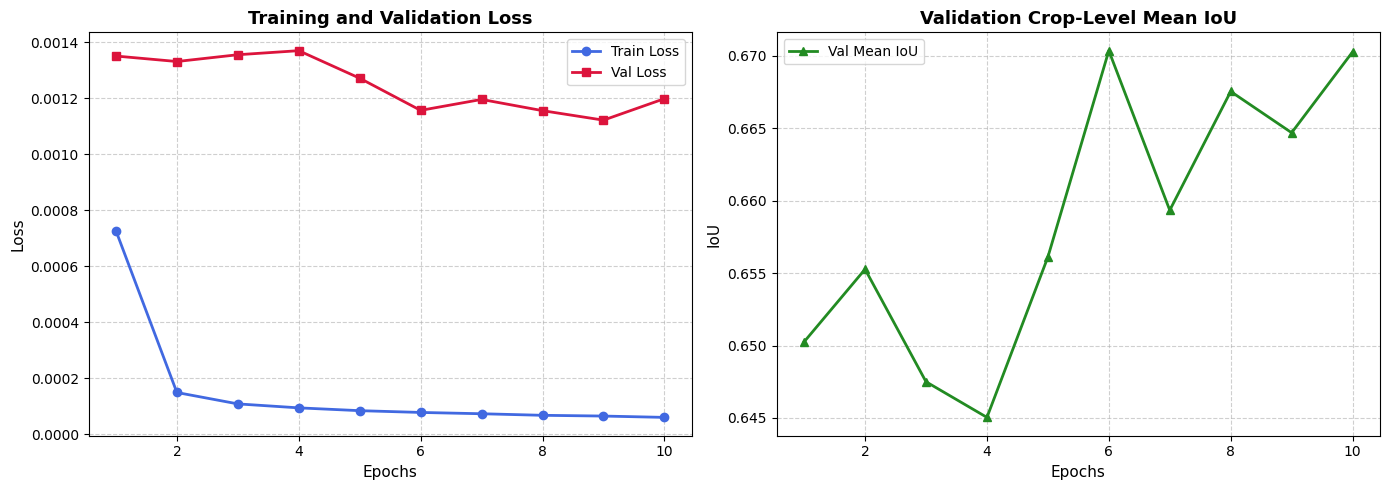

In [28]:
# TODO: Plot training and validation loss curves.
# TODO: Plot validation crop-level mean IoU.

# epoch range
epochs = range(1, len(history["train_loss"]) + 1)

# plot for training statistics
plt.figure(figsize=(14, 5))

# plot Train vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss", color="royalblue", marker="o", linewidth=2)
plt.plot(epochs, history["val_loss"], label="Val Loss", color="crimson", marker="s", linewidth=2)
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.title("Training and Validation Loss", fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# plot Validation Crop-Level Mean IoU
plt.subplot(1, 2, 2)
plt.plot(epochs, history["val_iou"], label="Val Mean IoU", color="forestgreen", marker="^", linewidth=2)
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("IoU", fontsize=11)
plt.title("Validation Crop-Level Mean IoU", fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## 3.9 Visualize Crop-Level Validation Predictions

Visualize at least five validation crop predictions.

Draw:
- ground-truth box,
- predicted box.

This helps check whether the model learned meaningful localization.

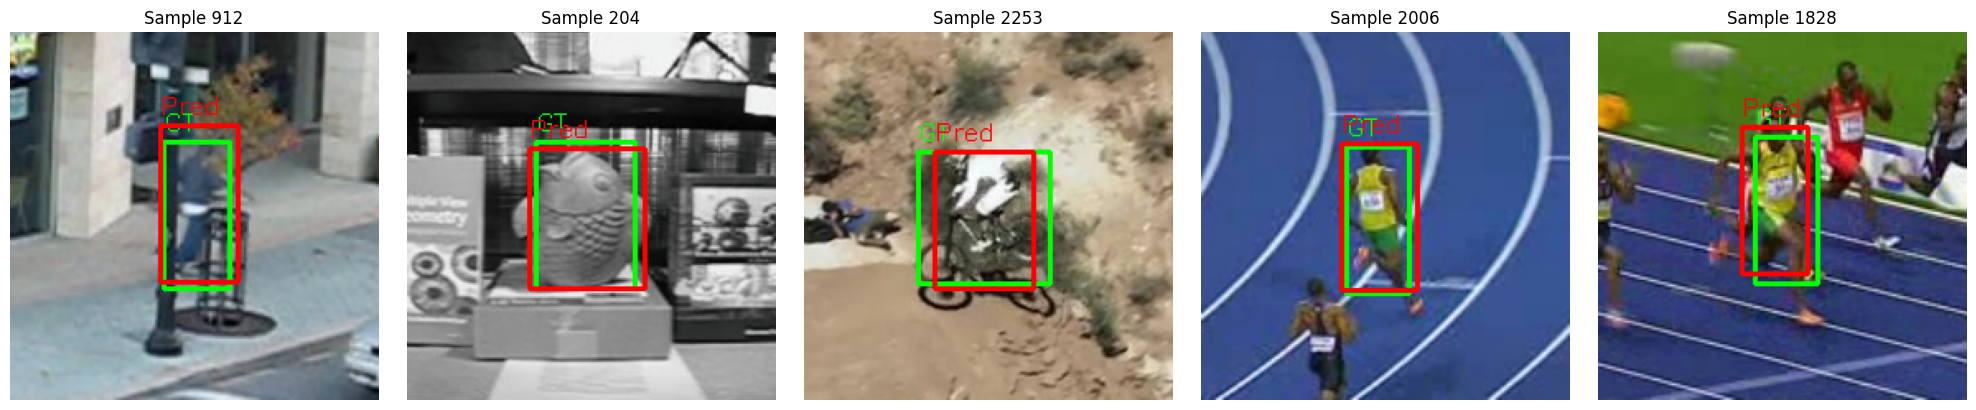

In [29]:
def denormalize_tensor_image(tensor_img: torch.Tensor) -> np.ndarray:
    """Convert a normalized tensor image back to a uint8 RGB image for visualization."""
    # convert (3, H, W) PyTorch tensor to (H, W, 3) NumPy array
    img_np = tensor_img.cpu().numpy().transpose(1, 2, 0)
    # imageNet mean and std values
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    # reverse normalization
    img_denorm = (img_np * std) + mean
    img_denorm = np.clip(img_denorm, 0.0, 1.0)

    # convert to uint8 format
    return (img_denorm * 255.0).astype(np.uint8)

@torch.no_grad()
def visualize_validation_predictions(model, dataset, num_samples: int = 5):
    """Visualize model predictions on validation crop samples."""
    model.eval()
    
    # select random sample indices from the dataset
    indices = random.sample(range(len(dataset)), num_samples)
    
    # create subplots for visualization
    fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
    
    for ax, idx in zip(axes, indices):
        # get item from dataset
        crop_tensor, target_tensor = dataset[idx]
        
        # forward pass
        inputs = crop_tensor.unsqueeze(0).to(DEVICE)
        pred_box = model(inputs).squeeze(0).cpu().numpy()
        
        # denormalize image crop
        img_rgb = denormalize_tensor_image(crop_tensor)
        
        # map target and prediction back to 224x224 pixel coordinates
        target_pixel = target_tensor.numpy() * 224.0
        pred_pixel = pred_box * 224.0
        
        # draw GT (green) and Prediction (red) boxes
        img_drawn = draw_bbox(img_rgb, target_pixel, color=(0, 255, 0), thickness=2, label="GT")
        img_drawn = draw_bbox(img_drawn, pred_pixel, color=(255, 0, 0), thickness=2, label="Pred")
        
        # plot image and turn off axis
        ax.imshow(img_drawn)
        ax.set_title(f"Sample {idx}")
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

# TODO: Visualize validation predictions
# visualize_validation_predictions(model, val_dataset, num_samples=5)
# Run the validation prediction visualization helper
val_dataset = SearchRegionDataset(DATA_ROOT, val_seqs, IMAGE_SIZE, SEARCH_SCALE, augment=False)
visualize_validation_predictions(model, val_dataset, num_samples=5)

# PART 4 — Single-Object Tracking on Validation and Test Sequences

After training the model, use it as a tracker.

For validation sequences:
- use the first line of `groundtruth_rect.txt` as initialization,
- predict all later frames,
- evaluate after tracking.

For test sequences:
- use `init_rect.txt` as initialization,
- predict all later frames,
- save CSV files,
- do not evaluate locally.

## 4.1 Evaluation-Time Preprocessing

Use the same preprocessing during tracking that you used during training.

Do not apply random augmentation during validation or test tracking.

In [30]:
eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

## 4.2 Predict a Box Inside One Crop

This helper runs the model on one search crop and returns a normalized crop-local bounding box.

In [31]:
@torch.no_grad()
def predict_bbox_in_crop(model, crop_rgb: np.ndarray, device: torch.device = DEVICE) -> np.ndarray:
    """Run the model on a crop and return normalized bbox prediction."""
    model.eval()

    # transform crop image and add batch dimension
    crop_tensor = eval_transform(crop_rgb).unsqueeze(0).to(device)
    
    # model inference
    pred_box = model(crop_tensor).squeeze(0).cpu().numpy()
    
    return pred_box

## 4.3 Tracking Loop

Implement the full single-object tracking loop.

The function should receive only:

```text
model
frame paths
initial bbox
```

It must not receive the full ground-truth array.

In [32]:
@torch.no_grad()
def track_sequence(
    model,
    frame_paths: List[Path],
    initial_bbox: np.ndarray,
    device: torch.device = DEVICE,
    scale: float = SEARCH_SCALE,
    image_size: int = IMAGE_SIZE,
) -> np.ndarray:
    """
    Track the target object through a sequence.

    Args:
        model: trained tracking model
        frame_paths: sorted list of frame paths
        initial_bbox: first-frame bbox, from GT or init_rect.txt
        device: torch device
        scale: search-region scale

    Returns:
        predictions: numpy array of shape (N, 4), full-frame bboxes

    Important:
        This function must not use ground-truth boxes after frame 1.
    """
    num_frames = len(frame_paths)
    predictions = np.zeros((num_frames, 4), dtype=np.float32)

    # 1. Initialize predictions with initial_bbox.
    predictions[0] = initial_bbox
    
    for t in range(1, num_frames):
        prev_bbox = predictions[t - 1]
        image = read_image_rgb(frame_paths[t])
        
        # ccreate search crop around previous prediction,
        crop_img, crop_info = crop_search_region(image, prev_bbox,scale=scale,output_size=image_size)
        
        # predict bbox inside crop,
        pred_box_norm = predict_bbox_in_crop(model, crop_img, device=device)
        
        # convert to full-frame coordinates,
        pred_box_full = crop_to_frame_coordinates(pred_box_norm,crop_info)
        
        # clip to image boundaries,
        pred_box_clipped = clip_bbox_to_image(pred_box_full, image.shape)
        # save prediction.
        predictions[t] = pred_box_clipped
        

    return predictions

## 4.4 Save Prediction CSV Files

Save predictions in the required format.

The saved coordinates must be full-frame pixel coordinates.

In [33]:
def save_predictions_csv(predictions: np.ndarray, output_path: Path):
    """
    Save predictions in CSV format:

    frame,x,y,w,h
    1,...
    2,...

    Coordinates must be full-frame pixel coordinates, not normalized crop coordinates.
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(output_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["frame", "x", "y", "w", "h"])
        
        for idx, bbox in enumerate(predictions, start=1):
            writer.writerow([idx, bbox[0], bbox[1], bbox[2], bbox[3]])

## 4.5 Run Tracking on Validation Sequences

Use the first validation ground-truth box for initialization.

Save validation predictions under:

```text
outputs/validation/
```

In [34]:
def run_tracking_on_validation_sequences(
    model,
    data_root: Path,
    sequence_names: List[str],
    output_root: Path,
    device: torch.device = DEVICE,
    scale: float = SEARCH_SCALE,
) -> Dict[str, np.ndarray]:
    """Track validation sequences and save CSV prediction files."""
    results = {}

    # For each validation sequence:
    for seq_name in sequence_names:
        seq_path = data_root / seq_name
        #   load frames and GT using load_sequence_with_gt
        frame_paths, gt_bboxes = load_sequence_with_gt(seq_path)
        
        #   use gt_bboxes[0] as initial_bbox
        initial_bbox = gt_bboxes[0]
        
        #   run track_sequence
        print(f"tracking validation sequence: {seq_name}")
        predictions = track_sequence(model, frame_paths, initial_bbox, device=device, scale=scale)
        
        #   save predictions

        csv_path = output_root / "validation" / f"{seq_name}_predictions.csv"
        save_predictions_csv(predictions, csv_path)
        
        results[seq_name] = predictions
        
    return results
    

## 4.6 Run Tracking on Test Sequences

Use `init_rect.txt` for initialization.

Save test predictions under:

```text
outputs/test/
```

These files will be submitted for evaluation.

In [35]:
def run_tracking_on_test_sequences(
    model,
    data_root: Path,
    sequence_names: List[str],
    output_root: Path,
    device: torch.device = DEVICE,
    scale: float = SEARCH_SCALE,
) -> Dict[str, np.ndarray]:
    """Track test sequences and save CSV prediction files."""
    results ={}
    
    # For each test sequence:
    for seq_name in sequence_names:
        seq_path = data_root / seq_name
        #   load frames and initial bbox using load_test_sequence
        frame_paths, initial_bbox = load_test_sequence(seq_path)
         #   run track_sequence
        print(f"tracking test sequence: {seq_name}")
        #   save predictions
        predictions = track_sequence(model, frame_paths, initial_bbox, device=device, scale=scale)
        # save to outputs/test/
        csv_path = output_root / "test" / f"{seq_name}_predictions.csv"
        save_predictions_csv(predictions, csv_path)
        
        results[seq_name] = predictions

    # TODO:
    
    
   
    return results
    

## 4.7 Execute Tracking

Run tracking on validation and test sequences.

Make sure the generated test CSV files are complete and correctly formatted.

In [36]:
# Run tracking on validation sequences
val_predictions = run_tracking_on_validation_sequences(
    model=model,
    data_root=DATA_ROOT,
    sequence_names=val_seqs,
    output_root=OUTPUT_ROOT,
    device=DEVICE,
    scale=SEARCH_SCALE
)

# Run tracking on hidden test sequences and save CSV files
test_predictions = run_tracking_on_test_sequences(
    model=model,
    data_root=DATA_ROOT,
    sequence_names=test_seqs,
    output_root=OUTPUT_ROOT,
    device=DEVICE,
    scale=SEARCH_SCALE
)

tracking validation sequence: Bird2
tracking validation sequence: Fish
tracking validation sequence: Human4
tracking validation sequence: ClifBar
tracking validation sequence: Bolt
tracking validation sequence: MountainBike
tracking validation sequence: CarDark
tracking validation sequence: Man
tracking validation sequence: Basketball
tracking validation sequence: Crowds
tracking validation sequence: Box
tracking test sequence: TestSeq1
tracking test sequence: TestSeq2
tracking test sequence: TestSeq3
tracking test sequence: TestSeq4
tracking test sequence: TestSeq5
tracking test sequence: TestSeq6
tracking test sequence: TestSeq7


# Required Test Output Format

For each test sequence, save one CSV file:

```text
outputs/test/<sequence_name>_predictions.csv
```

Each CSV file must contain:

```text
frame,x,y,w,h
```

Rules:

1. Number of rows must equal the number of frames.
2. Frame numbering must start from 1.
3. The first-frame prediction should be the initialization box from `init_rect.txt`.
4. Coordinates must be full-frame pixel coordinates.
5. Do not save normalized crop coordinates.
6. Bounding boxes must be in `(x, y, width, height)` format.

# PART 5 — Validation Evaluation and Analysis

Evaluate your tracker on validation sequences using the provided validation ground truth.

Do not evaluate test sequences. Test ground truth is hidden and will be evaluated by the instructors.

Required validation metrics:

1. Mean IoU  
2. Success Rate @ IoU ≥ 0.5  
3. Average Center Error  
4. Failure Count, where failure means IoU < 0.1

## 5.1 Metric Functions

Implement IoU, center error, and sequence-level evaluation.

In [37]:
def compute_iou(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """Compute intersection-over-union between two boxes in (x, y, w, h) format."""
    return compute_iou_np(box_a, box_b)
    


def compute_center_error(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """Compute Euclidean distance between the centers of two boxes."""
    # get the centers
    ca_x, ca_y = bbox_center(box_a)
    cb_x, cb_y = bbox_center(box_b)

    # euclidain distance calculation
    distance = np.sqrt((ca_x - cb_x) ** 2 + (ca_y - cb_y) ** 2)
    return float(distance)


def evaluate_sequence(
    predictions: np.ndarray,
    ground_truth: np.ndarray,
    success_iou_threshold: float = 0.5,
    failure_iou_threshold: float = 0.1,
) -> Dict[str, float]:
    """
    Evaluate one validation tracking sequence.

    Returns:
        metrics dictionary with:
        - mean_iou
        - success_rate_0.5
        - avg_center_error
        - failure_count
        - num_frames
    """

    num_frames = len(predictions)
    ious = []
    center_errors = []
    success_count = 0
    failure_count = 0

    # loop through each frame in the sequence
    for i in range(num_frames):
        pred_box = predictions[i]
        gt_box = ground_truth[i]
        
        # calculate IoU and Center Error
        iou = compute_iou(pred_box, gt_box)
        error = compute_center_error(pred_box, gt_box)
        
        ious.append(iou)
        center_errors.append(error)
        
        # track success and failure states
        if iou >= success_iou_threshold:
            success_count += 1
        if iou < failure_iou_threshold:
            failure_count += 1
            
    # compute mean metrics over all frames
    mean_iou = np.mean(ious)
    success_rate = success_count / num_frames
    avg_center_error = np.mean(center_errors)
    
    return {
        "mean_iou": float(mean_iou),
        "success_rate_0.5": float(success_rate),
        "avg_center_error": float(avg_center_error),
        "failure_count": int(failure_count),
        "num_frames": int(num_frames)
    }
    

## 5.2 Evaluate All Validation Sequences

Create a result table with one row per validation sequence and one final average row.

In [38]:
def evaluate_validation_sequences(
    predictions_by_sequence: Dict[str, np.ndarray],
    data_root: Path,
) -> pd.DataFrame:
    """Evaluate all validation sequences and return a result table."""
    rows = []
    
    for seq_name, preds in predictions_by_sequence.items():
        # load ground-truth bounding boxes
        _, gt_bboxes = load_sequence_with_gt(data_root / seq_name)
        
        # Evaluate metrics for the current sequence
        metrics = evaluate_sequence(preds, gt_bboxes)
        
        rows.append({
            "Sequence": seq_name,
            "Mean IoU": metrics["mean_iou"],
            "Success Rate @0.5": metrics["success_rate_0.5"],
            "Avg. Center Error": metrics["avg_center_error"],
            "Failure Count": metrics["failure_count"]
        })
        
    # create pandas DataFrame
    df = pd.DataFrame(rows)
    
    # calculate average values for all metrics
    avg_row = {
        "Sequence": "Average",
        "Mean IoU": df["Mean IoU"].mean(),
        "Success Rate @0.5": df["Success Rate @0.5"].mean(),
        "Avg. Center Error": df["Avg. Center Error"].mean(),
        "Failure Count": df["Failure Count"].mean()
    }
    
    # append average row to the DataFrame
    df = pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)
    
    return df

# TODO: Evaluate validation predictions
val_metrics_df = evaluate_validation_sequences(val_predictions, DATA_ROOT)
val_metrics_df

,Sequence,Mean IoU,Success Rate @0.5,Avg. Center Error,Failure Count
0,Bird2,0.295615,0.242424,56.308427,37.0
1,Fish,0.023607,0.018908,65.427881,453.0
2,Human4,0.042447,0.007496,340.961271,570.0
3,ClifBar,0.012809,0.010593,38.185408,462.0
4,Bolt,0.017101,0.011429,324.286822,337.0
5,MountainBike,0.041402,0.008772,32.405222,196.0
6,CarDark,0.078129,0.053435,21.157404,315.0
7,Man,0.792921,0.992537,3.051110,0.0
8,Basketball,0.020268,0.002759,291.389336,671.0
9,Crowds,0.201326,0.250720,93.367383,232.0


## 5.3 Visualize Validation Tracking Results

Visualize tracking results for at least three validation sequences.

For each selected sequence, show:
- an early frame,
- a middle frame,
- a late frame.

Draw both the ground-truth and predicted bounding boxes.

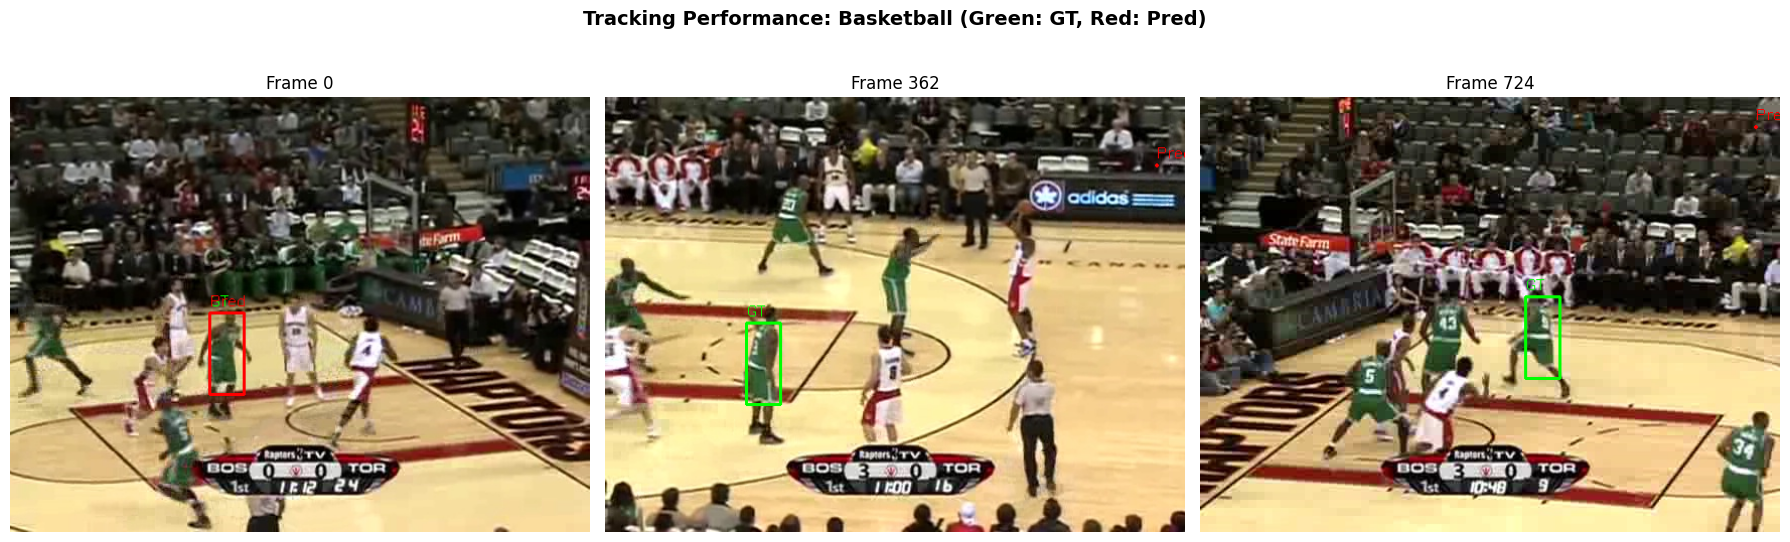

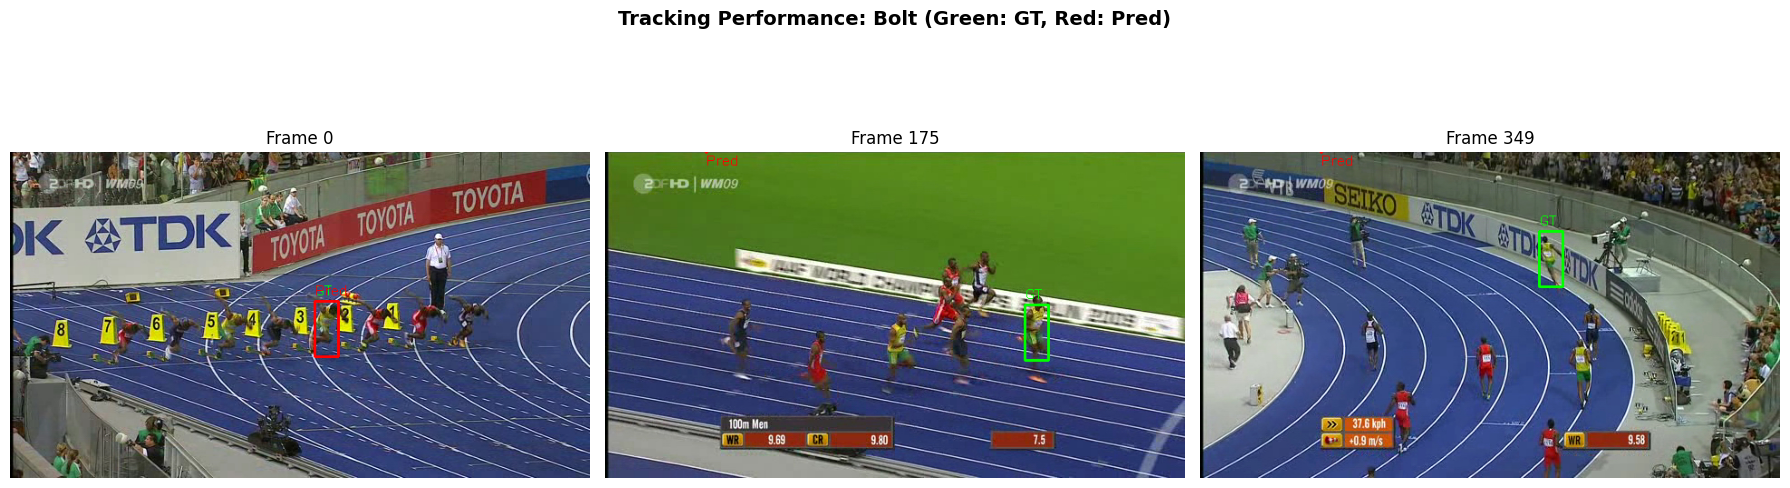

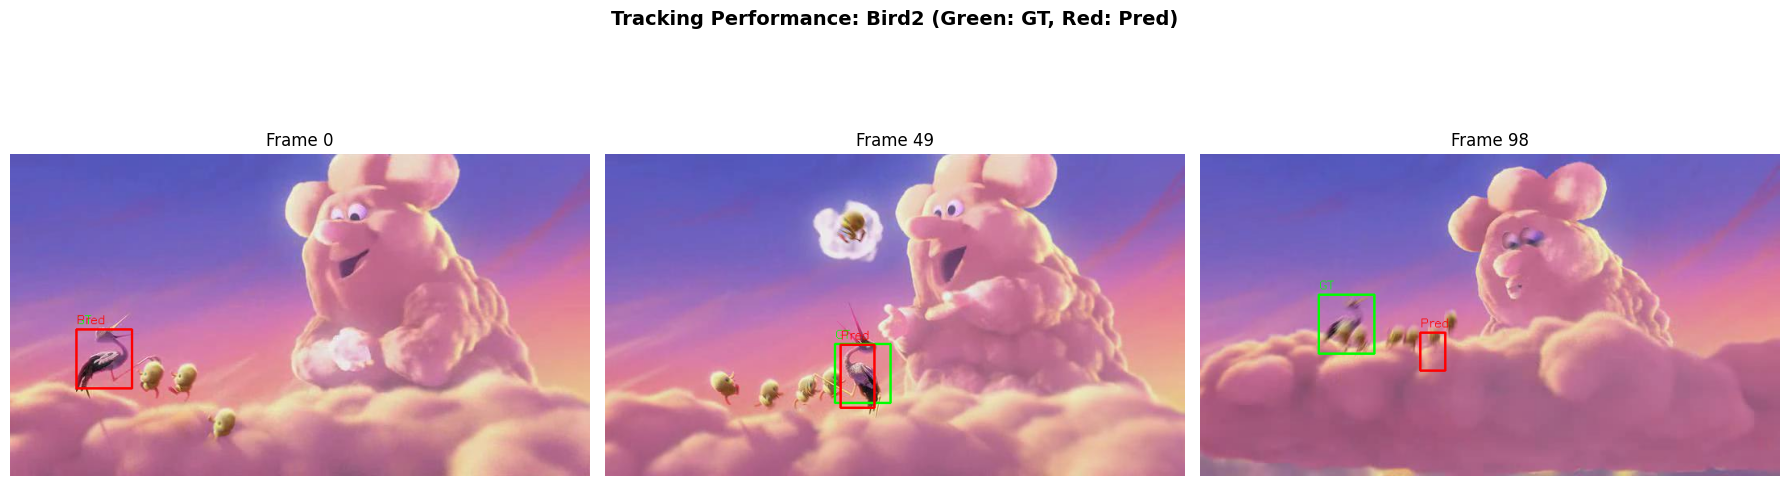

In [39]:
def visualize_validation_tracking_result(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    frame_indices: Optional[List[int]] = None,
):
    """Visualize tracking predictions and ground truth for selected validation frames."""
    # load sequence paths and ground truth
    frame_paths, gt_bboxes = load_sequence_with_gt(data_root / sequence_name)
    num_frames = len(frame_paths)
    
    # select early, middle, and late frames if indices are not provided
    if frame_indices is None:
        frame_indices = [0, num_frames // 2, num_frames - 1]
        
    # create a beautiful subplot of 3 images
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for ax, idx in zip(axes, frame_indices):
        img = read_image_rgb(frame_paths[idx])
        
        # draw ground-truth (green) and predictions (red)
        img_drawn = draw_bbox(img, gt_bboxes[idx], color=(0, 255, 0), thickness=2, label="GT")
        img_drawn = draw_bbox(img_drawn, predictions[idx], color=(255, 0, 0), thickness=2, label="Pred")
        
        ax.imshow(img_drawn)
        ax.set_title(f"Frame {idx}", fontsize=12)
        ax.axis("off")
        
    plt.suptitle(f"Tracking Performance: {sequence_name} (Green: GT, Red: Pred)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# visualize tracking results for at least three validation sequences

sequences_to_plot = ["Basketball", "Bolt", "Bird2"]
for seq in sequences_to_plot:
    visualize_validation_tracking_result(
        sequence_name=seq,
        predictions=val_predictions[seq],
        data_root=DATA_ROOT
    )

## 5.4 Failure-Case Analysis

Find frames where the tracker performs poorly.

At minimum, show:
- three successful frames,
- three failure cases.

For each failure case, explain what went wrong.

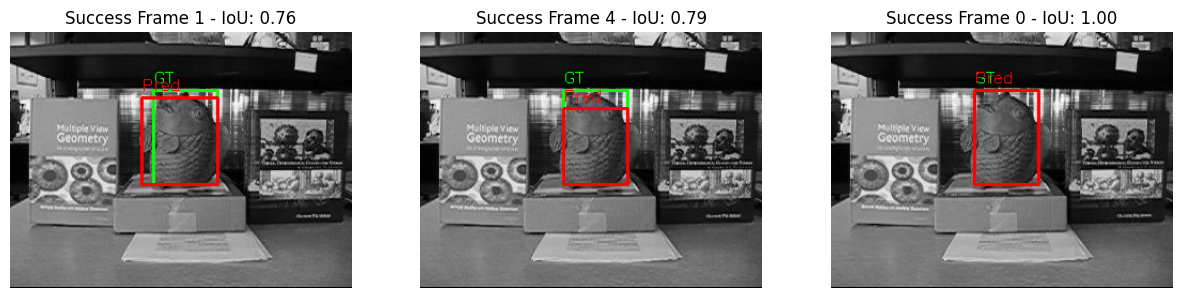

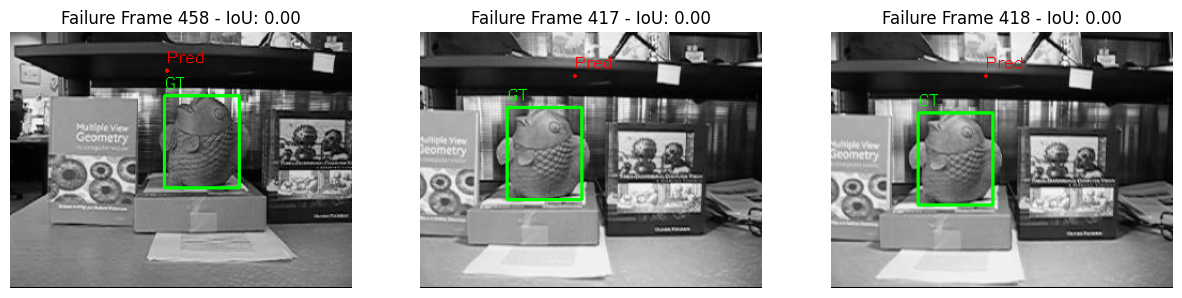

In [40]:
def find_worst_validation_frames(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    k: int = 3,
) -> List[int]:
    """Return indices of the k validation frames with the lowest IoU."""
    # load ground truth
    _, gt_bboxes = load_sequence_with_gt(data_root / sequence_name)
    
    # compute IoU for each frame
    ious = [compute_iou(predictions[i], gt_bboxes[i]) for i in range(len(predictions))]
    
    # sort indices by IoU in ascending order and take first k elements
    worst_indices = np.argsort(ious)[:k]
    
    return list(worst_indices)


# load sequence data
seq = "Fish"
frame_paths, gt_bboxes = load_sequence_with_gt(DATA_ROOT / seq)
preds = val_predictions[seq]

# compute all IoU values
ious = [compute_iou(preds[i], gt_bboxes[i]) for i in range(len(preds))]

# get indices for best and worst frames
worst_idx = np.argsort(ious)[:3]
best_idx = np.argsort(ious)[-3:]

# plot 3 successful frames (Highest IoU)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, best_idx):
    img = read_image_rgb(frame_paths[idx])
    img = draw_bbox(img, gt_bboxes[idx], color=(0, 255, 0), label="GT")
    img = draw_bbox(img, preds[idx], color=(255, 0, 0), label="Pred")
    ax.imshow(img)
    ax.set_title(f"Success Frame {idx} - IoU: {ious[idx]:.2f}")
    ax.axis("off")
plt.show()

# plot 3 failure frames (Lowest IoU)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, worst_idx):
    img = read_image_rgb(frame_paths[idx])
    img = draw_bbox(img, gt_bboxes[idx], color=(0, 255, 0), label="GT")
    img = draw_bbox(img, preds[idx], color=(255, 0, 0), label="Pred")
    ax.imshow(img)
    ax.set_title(f"Failure Frame {idx} - IoU: {ious[idx]:.2f}")
    ax.axis("off")
plt.show()


# Optional — Tracking Video Export

You may create MP4 visualizations of your validation tracking results.

This is optional, but it can help you inspect long sequences more easily.

In [41]:
def create_validation_tracking_video(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    output_path: Path,
    fps: int = 20,
):
    """Create an MP4 video showing ground-truth and predicted boxes for a validation sequence."""
    # TODO: Optional implementation

    sequence_path = Path(data_root) / sequence_name
    frame_paths, gt_bboxes = load_sequence_with_gt(sequence_path)
    
    # ensure the output directory exists
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    # get frame dimensions from the first frame
    first_frame = read_image_rgb(frame_paths[0])
    height, width, _ = first_frame.shape
    
    # setup the VideoWriter with MP4 codec
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    video_writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    print(f"Generating video for sequence '{sequence_name}'...")
    print(f"Total frames: {len(frame_paths)}")
    
    # iterate through frames, draw bounding boxes and IoU
    for i, frame_path in enumerate(frame_paths):
        # load frame in RGB
        img = read_image_rgb(frame_path)
        
        # draw Ground-Truth bounding box in green
        if i < len(gt_bboxes):
            img = draw_bbox(img, gt_bboxes[i], color=(0, 255, 0), label="GT")
            
        # draw Predicted bounding box in red
        if i < len(predictions):
            img = draw_bbox(img, predictions[i], color=(255, 0, 0), label="Pred")
            
            # optional: calculate and draw current frame IoU on top-left
            if i < len(gt_bboxes):
                iou = compute_iou(gt_bboxes[i], predictions[i])
                text = f"Frame: {i} | IoU: {iou:.3f}"
                cv2.putText(
                    img,
                    text,
                    (15, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 255, 255),
                    2,
                    cv2.LINE_AA,
                )
                
        # openCV VideoWriter expects BGR format, convert from RGB
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        video_writer.write(img_bgr)
        
    # release the video writer to finalize the file
    video_writer.release()
    print(f"Successfully saved tracking video to: {output_path}")
    

In [42]:
# Test the implementation on the 'Man' validation sequence
output_video_path = Path("outputs/validation/bolt_tracking.mp4")

create_validation_tracking_video(
    sequence_name="Bolt",
    predictions=val_predictions["Bolt"],
    data_root=DATA_ROOT,
    output_path=output_video_path,
    fps=20
)


Generating video for sequence 'Bolt'...
Total frames: 350
Successfully saved tracking video to: outputs\validation\bolt_tracking.mp4


# Discussion Questions

Write your discussions about the performance, best/failure cases, metrics, etc.

Use your validation metrics, visualizations, and failure cases as evidence.

## Discussion - Tracker Performance Analysis

The implemented tracker follows a CNN-based bounding-box regression approach using a pretrained ResNet18 backbone. During training, the model achieves a validation IoU of approximately 0.67, which tells that the model can successfully localize the target object inside a local search region. However, sequence-level tracking performance is significantly lower. Which we know that with the difficulty of accumulated error in single-object tracking. When I examined the videos that created by model, I saw that the box cannot go as fast as the groundtruth box which causes to IoU value to be 0. Even though it finds the object at starting, it misses the object.

### Hyperparameter Chocies 
A search-region scale of 2.5 was used, which defines the search area as 2.5 times the maximum dimension of the previous bounding box. This provides enough context for small motion while keeping the object reasonably large in the crop. Padding with a constant gray value (128, 128, 128) was used to handle boundary cases, as clipping would cause the crop_info coordinates to be inconsistent with the actual crop content, leading to incorrect coordinate transformations.

Also on one test I used a search-region scale of 3 which caused to worse results.

Data jittering was applied during training by adding random positional noise (±10% of 
bbox dimensions) to the previous bounding box before cropping. The model generalized better to slightly misaligned crops, which is closer to the real tracking scenario where the previous prediction may not be perfectly accurate by the help of it.

### Success Cases

**1. Man sequence (Mean IoU ≈ 0.76)**  

The tracker performs well on the Man sequence because the target moves slowly and the background is relatively simple. Since the object displacement between consecutive frames is small, the search region always contains the target. The model can reliably localize it, and errors do not accumulate significantly.

**2. Bird2 sequence – Distinct Appearance**  
The bird has a clearly distinguishable appearance against the sky background. In frames where the bird moves slowly and stays within the search region, the tracker maintains reasonable predictions. The relatively low failure count compared to other sequences confirms that the tracker can handle this type of target when conditions are favorable.

### Failure Cases

**1. Box sequence (Mean IoU ≈ 0.009) – Occlusion**

When we look at the video we see that the box is repeatedly occluded by other objects. Once the tracker loses the target due to occlusion, it has no re-detection mechanism and continues to track the wrong region. The failure count of over 1000 frames shows that the tracker effectively loses the target within the first few frames and never recovers which is same as I talked about. When I made a research about it I saw that this is a fundamental limitation of single-pass trackers without a template update strategy.

**2. Basketball sequence (Mean IoU ≈ 0.010) – Crowded scene**  
Multiple players with similar appearances make it very hard for the model to distinguish the correct target. Once the tracker drifts slightly toward a nearby player, it cannot correct itself. Additionally, fast basketball motion often  causes the target to leave the search region entirely. It is common to model to find the audince as the correct target.


**3. Fish sequence (Mean IoU ≈ 0.008) – Scale change and appearance similarity**  
The fish changes scale as it moves toward and away from the camera. The fixed-scale search region (2.5x) does not adapt to this. Furthermore, the fish and its background have very similar textures, making localization particularly difficult for the CNN.


### Why is Sequence-Level Performance Lower Than Crop-Level?
The main reason for this gap is error accumulation (tracking drift). During training, crops are always generated using ground-truth bounding boxes, meaning the target is always visible and approximately centered. During tracking, however, the model's own predictions are fed back as the next search region. Even a small localization error in one frame causes the next crop to be slightly misaligned, leading to a larger error, and so on. When jittering applied it did not caused better results as I expected. This train-test distribution mismatch is a well-known challenge in appearance-based tracking. Another contributing factor is that the ResNet18 backbone uses Global Average Pooling, which discards spatial information. A model that preserves spatial feature maps (e.g., using a fully convolutional head) might produce more precise localization. Maybe better model choice should be made in Sequence-Level.

### Potential Improvements

- **Adaptive scale**: adjusting the search region size based on the predicted bounding box size could improve robustness to scale change.
- **Template update**: periodically updating the reference appearance using high-confidence predictions could reduce drift.
- **Prediction smoothing**: applying an exponential moving average on predictions could reduce sudden jumps.
- **Perturbed training**: training with randomly shifted previous bounding boxes (as implemented via data jittering) should reduce the train-test distribution gap.

### Last Comment

While learining the subject theoretically it seemed that the results would be good. But seeing such results as basketball and fish sequence showed me that the it is not always the case. We should think more broadly and adapt our approach to each task, as different problems may require fundamentally different engineering solutions. Also every model cannot generalize very well it can be perfect for some jobs while being the worse for some as we saw in fish sequence.

# Final Implementation Summary

Before submission, summarize your final settings here.

## Final Settings

* **Backbone architecture:** ResNet18
* **Pretrained weights used?** Yes (ImageNet)
* **Input size:** 224*224
* **Search-region scale:** 2.5  
* **Batch size:** 32
* **Learning rate:** 1e-4  
* **Number of epochs:** 10
* **Optimizer:** Adam
* **Loss function:** Smooth L1

# Submission Checklist

Before submitting, make sure that:

- [ ] Your notebook runs from beginning to end without manual intervention.
- [ ] Your codes are written clear with proper descriptions.
- [ ] You use only the provided train/validation/test splits.
- [ ] You do not use ground-truth boxes after the first frame during validation tracking.
- [ ] Your validation result table is included in the notebook.
- [ ] Your visualizations and failure analysis are included in the notebook.
- [ ] Your test prediction CSV files are saved under `outputs/test/`.
- [ ] Your CSV files contain full-frame pixel coordinates, not normalized crop coordinates.
- [ ] Your discussions are completed.
- [ ] You included the checkpoint (model weights) to the `checkpoint/` folder.

link for videos and photos : https://drive.google.com/drive/folders/1_uBPzWLBoxEMpn4nFV1ri0lH-L-qXc4m?usp=drive_link
